In [25]:
# Dubins car — vanilla receding-horizon MPC for reach-avoid

In [26]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import casadi as ca

# ── Symbolic variables ────────────────────────────────────────────────────────
x1, x2, th, v = sp.symbols("x1 x2 th v")
y1, y2 = sp.symbols("y1 y2")
state_vars = [x1, x2, th, v]

# ── Dubins-car dynamics:  xdot = f(x) + g(x)*u ───────────────────────────────
#   state   = [x1, x2, th, v]   (position, heading, speed)
#   control = [u1, u2]           (angular-velocity, acceleration)
f_sym = sp.Matrix([v * sp.cos(th), v * sp.sin(th), 0, 0])
g_sym = sp.Matrix([[0, 0], [0, 0], [1, 0], [0, 1]])
hx = sp.Matrix([x1, x2])  # output map  y = h(x) = [x1, x2]

# ── Sets in output (y) space ─────────────────────────────────────────────────
#   safe_set_y  >= 0  ↔  inside safe region
#   target_set_y <= 0  ↔  inside target region
h_raw = -(y1**4 + y2**4 - 16) * (y1**4 + y2**4 - 4)
target_set_y = (y2 - 0) ** 2 + (2 * (y1 + 1.7)) ** 2 - 0.4
alpha = 1e-3 * (-target_set_y + 300)
safe_set_y = alpha * h_raw

safe_set_x = safe_set_y.subs({y1: hx[0], y2: hx[1]})
target_set_x = target_set_y.subs({y1: hx[0], y2: hx[1]})

# ── Numpy callables ───────────────────────────────────────────────────────────
safe_set_y_func = sp.lambdify([y1, y2], safe_set_y, "numpy")
target_set_y_func = sp.lambdify([y1, y2], target_set_y, "numpy")
safe_set_x_func = sp.lambdify(state_vars, safe_set_x, "numpy")
target_set_x_func = sp.lambdify(state_vars, target_set_x, "numpy")
hx_func = sp.lambdify(state_vars, hx, "numpy")

print("safe_set   (y):", safe_set_y)
print("target_set (y):", target_set_y)

safe_set   (y): (-y1**4 - y2**4 + 16)*(y1**4 + y2**4 - 4)*(-0.001*y2**2 - 0.001*(2*y1 + 3.4)**2 + 0.3004)
target_set (y): y2**2 + (2*y1 + 3.4)**2 - 0.4


In [27]:
# ── CasADi MPC formulation ────────────────────────────────────────────────────
dt_mpc = 0.1  # MPC discretisation step [s]
N_hor = 15  # prediction horizon (steps)
u1_max = 3.0  # angular-velocity bound [rad/s]
u2_max = 2.0  # acceleration bound     [m/s²]
TARGET_POS = np.array([-1.7, 0.0])  # centre of target set in position space

# ── CasADi continuous dynamics ───────────────────────────────────────────────
xc = ca.MX.sym("x", 4)
uc = ca.MX.sym("u", 2)
fc = ca.vertcat(xc[3] * ca.cos(xc[2]), xc[3] * ca.sin(xc[2]), uc[0], uc[1])
rhs_ca = ca.Function("f", [xc, uc], [fc])


def rk4_ca(x, u):
    k1 = rhs_ca(x, u)
    k2 = rhs_ca(x + dt_mpc / 2 * k1, u)
    k3 = rhs_ca(x + dt_mpc / 2 * k2, u)
    k4 = rhs_ca(x + dt_mpc * k3, u)
    return x + (dt_mpc / 6) * (k1 + 2 * k2 + 2 * k3 + k4)


def safe_ca(x):
    """Safe-set function in CasADi arithmetic (>= 0 means safe)."""
    y1v, y2v = x[0], x[1]
    h = -(y1v**4 + y2v**4 - 16) * (y1v**4 + y2v**4 - 4)
    tgt = y2v**2 + (2 * (y1v + 1.7)) ** 2 - 0.4
    alp = 1e-3 * (-tgt + 300)
    return alp * h


def target_ca(x):
    """Target-set function in CasADi arithmetic (<= 0 means inside target)."""
    y1v, y2v = x[0], x[1]
    return y2v**2 + (2 * (y1v + 1.7)) ** 2 - 0.4


_IPOPT_OPTS = {
    "ipopt.print_level": 0,
    "print_time": 0,
    "ipopt.max_iter": 400,
    "ipopt.tol": 1e-4,
    "ipopt.acceptable_tol": 1e-3,
}


def solve_mpc(x0_val, U_warm=None):
    """
    Solve the N_hor-step reach-avoid MPC from x0_val.

    Hard constraints
    ----------------
    * safe_ca(x_k) >= 0  for k = 0 … N_hor   (stay safe)
    * target_ca(x_N) <= 0                     (terminal state inside target)

    Feasibility of this problem determines whether a point is reachable
    under MPC within the planning horizon.

    Returns
    -------
    feasible : bool
    U_opt    : ndarray shape (2, N_hor), or None if infeasible
    """
    opti = ca.Opti()
    X = opti.variable(4, N_hor + 1)
    U = opti.variable(2, N_hor)

    x0_np = np.asarray(x0_val, dtype=float).flatten()
    opti.subject_to(X[:, 0] == x0_np)

    # Dynamics + safety constraints along the horizon
    for k in range(N_hor):
        opti.subject_to(X[:, k + 1] == rk4_ca(X[:, k], U[:, k]))
        opti.subject_to(safe_ca(X[:, k]) >= 0)
    opti.subject_to(safe_ca(X[:, N_hor]) >= 0)

    # ── Terminal constraint: reach the target set ─────────────────────────────
    opti.subject_to(target_ca(X[:, N_hor]) <= 0)

    # Control bounds
    opti.subject_to(opti.bounded(-u1_max, U[0, :], u1_max))
    opti.subject_to(opti.bounded(-u2_max, U[1, :], u2_max))

    # Objective: minimise control effort (feasibility already enforced by constraints)
    obj = ca.sumsqr(U)
    opti.minimize(obj)

    # ── Warm start ────────────────────────────────────────────────────────────
    if U_warm is not None:
        U_ws = np.hstack([U_warm[:, 1:], U_warm[:, -1:]])  # shift by 1 step
        X_ws = np.zeros((4, N_hor + 1))
        X_ws[:, 0] = x0_np
        for k in range(N_hor):
            xk, uk = X_ws[:, k], U_ws[:, k]
            X_ws[:, k + 1] = xk + dt_mpc * np.array(
                [xk[3] * np.cos(xk[2]), xk[3] * np.sin(xk[2]), uk[0], uk[1]]
            )
        opti.set_initial(X, X_ws)
        opti.set_initial(U, U_ws)
    else:
        tgt_full = np.array([TARGET_POS[0], TARGET_POS[1], x0_np[2], 0.0])
        X_ws = np.array(
            [(1 - k / N_hor) * x0_np + (k / N_hor) * tgt_full for k in range(N_hor + 1)]
        ).T  # (4, N_hor+1)
        opti.set_initial(X, X_ws)
        opti.set_initial(U, 0)

    opti.solver("ipopt", _IPOPT_OPTS)
    try:
        sol = opti.solve()
        return True, sol.value(U)
    except Exception:
        return False, None


print(f"MPC ready: N_hor={N_hor}, dt={dt_mpc} s, " f"u_bounds=[±{u1_max}, ±{u2_max}]")
print("Terminal constraint: target_set(x_N) <= 0  (must reach target within horizon)")

MPC ready: N_hor=15, dt=0.1 s, u_bounds=[±3.0, ±2.0]
Terminal constraint: target_set(x_N) <= 0  (must reach target within horizon)


In [28]:
# ── Sample the 4-D state space (same seed & bounds as unconstrained notebook) ─
N_samples = 500
np.random.seed(42)

lower_bound = np.array([-2.0, -2.0, 2 * np.pi / 3, -1.0])
upper_bound = np.array([2.0, 2.0, 4 * np.pi / 3, 1.0])

x_samples = np.random.rand(4, N_samples) * (upper_bound - lower_bound).reshape(
    -1, 1
) + lower_bound.reshape(-1, 1)

safe_vals = np.atleast_1d(np.squeeze(safe_set_x_func(*x_samples)))
target_vals = np.atleast_1d(np.squeeze(target_set_x_func(*x_samples)))

# Candidates: inside safe set AND outside target set
candidate_mask = (safe_vals >= 0) & (target_vals > 0)
candidate_idx = np.where(candidate_mask)[0]
print(f"Total samples : {N_samples}")
print(f"Candidates (safe & outside target): {len(candidate_idx)}")

# ── Check MPC feasibility for every candidate in parallel ─────────────────────
from joblib import Parallel, delayed


def _check_one(idx):
    ok, _ = solve_mpc(x_samples[:, idx])
    return idx, ok


print(
    f"\nChecking MPC feasibility ({len(candidate_idx)} candidates, "
    f"N_hor={N_hor}, dt={dt_mpc}s) ..."
)

results = Parallel(n_jobs=-1, prefer="processes", verbose=5)(
    delayed(_check_one)(idx) for idx in candidate_idx
)

mpc_feasible_idx = np.array([idx for idx, ok in results if ok])
mpc_infeasible_idx = np.array([idx for idx, ok in results if not ok])

n_c = len(candidate_idx)
print(
    f"\nMPC feasible:   {len(mpc_feasible_idx):3d} / {n_c}  "
    f"({100*len(mpc_feasible_idx)/n_c:.1f}%)"
)
print(
    f"MPC infeasible: {len(mpc_infeasible_idx):3d} / {n_c}  "
    f"({100*len(mpc_infeasible_idx)/n_c:.1f}%)"
)

Total samples : 500
Candidates (safe & outside target): 226

Checking MPC feasibility (226 candidates, N_hor=15, dt=0.1s) ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  84 tasks      | elapsed:    1.7s



MPC feasible:    93 / 226  (41.2%)
MPC infeasible: 133 / 226  (58.8%)


[Parallel(n_jobs=-1)]: Done 207 out of 226 | elapsed:    3.9s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done 226 out of 226 | elapsed:    4.0s finished


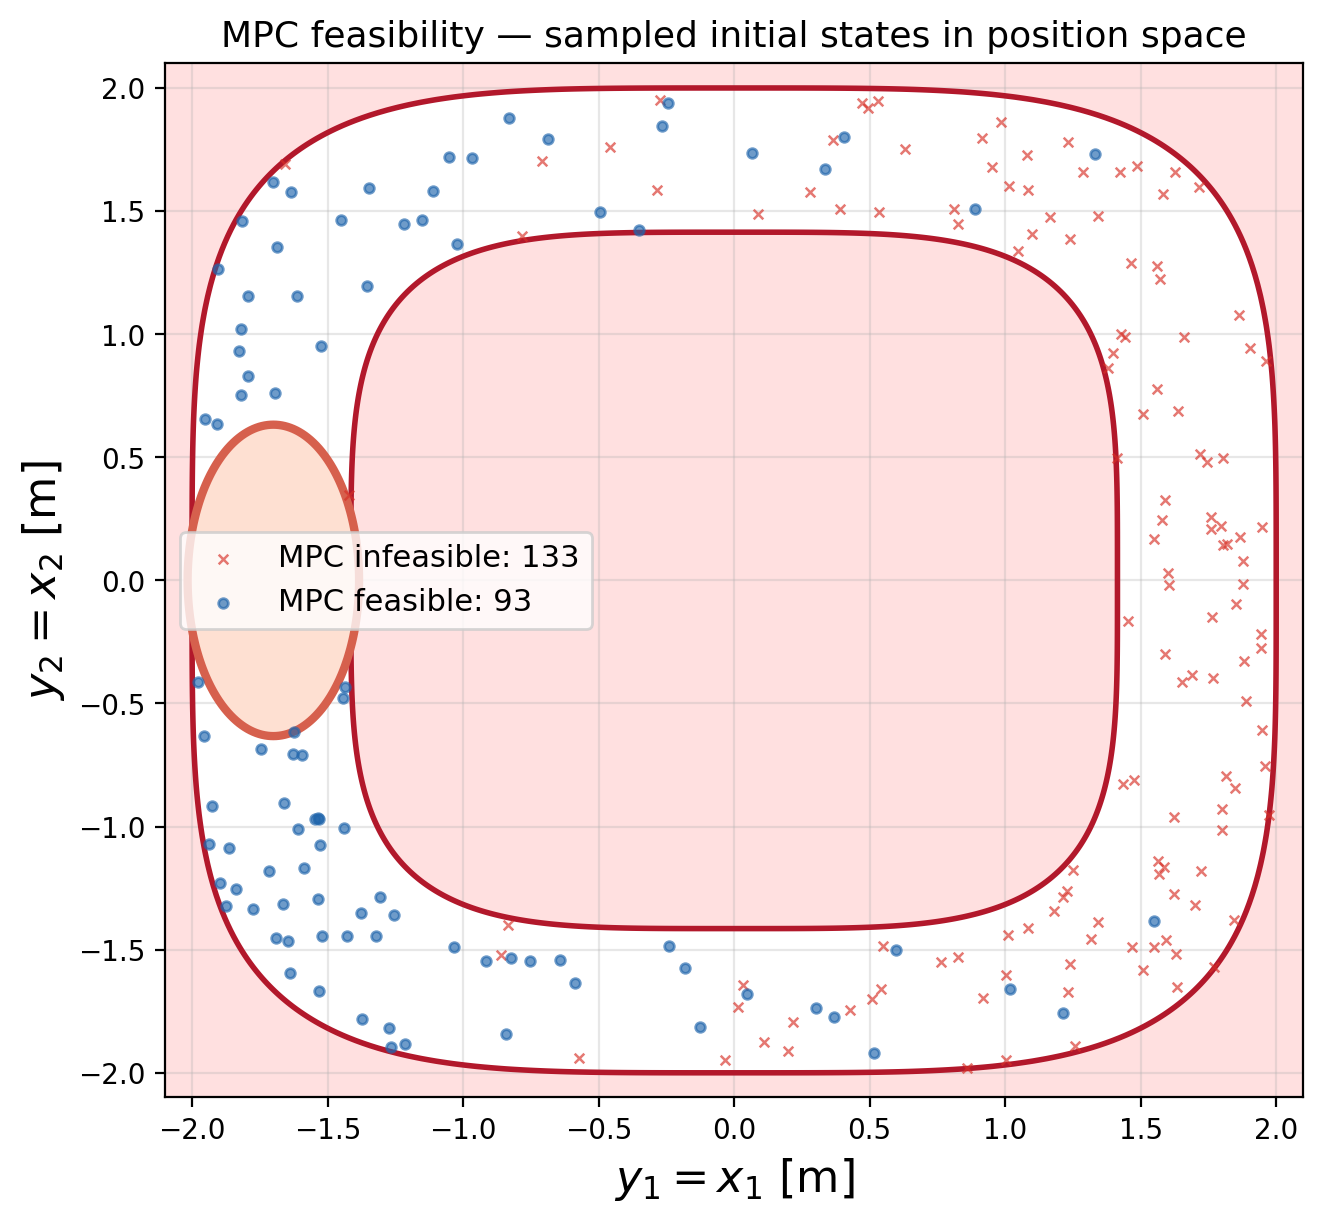

In [29]:
# ── Visualise MPC-feasible / MPC-infeasible initial states ────────────────────
y_feasible = np.array(hx_func(*x_samples[:, mpc_feasible_idx])).reshape(2, -1)
y_infeasible = np.array(hx_func(*x_samples[:, mpc_infeasible_idx])).reshape(2, -1)

n_grid = 400
y1_g = np.linspace(-2.1, 2.1, n_grid)
y2_g = np.linspace(-2.1, 2.1, n_grid)
Y1, Y2 = np.meshgrid(y1_g, y2_g)
Z_safe = safe_set_y_func(Y1, Y2)
Z_target = target_set_y_func(Y1, Y2)

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)

# Unsafe region
ax.contourf(
    Y1, Y2, Z_safe, levels=[-np.inf, 0], colors=["#ffcccc"], alpha=0.6, zorder=1
)
ax.contour(Y1, Y2, Z_safe, levels=[0], colors=["#b2182b"], linewidths=2, zorder=2)
# Target region
ax.contourf(
    Y1, Y2, Z_target, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=3
)
ax.contour(Y1, Y2, Z_target, levels=[0], colors=["#d6604d"], linewidths=3, zorder=4)

ax.scatter(
    y_infeasible[0],
    y_infeasible[1],
    s=12,
    color="#d73027",
    alpha=0.65,
    marker="x",
    linewidths=0.9,
    label=f"MPC infeasible: {len(mpc_infeasible_idx)}",
    zorder=9,
)
ax.scatter(
    y_feasible[0],
    y_feasible[1],
    s=12,
    color="#2166ac",
    alpha=0.65,
    marker="o",
    label=f"MPC feasible: {len(mpc_feasible_idx)}",
    zorder=10,
)

ax.set_xlabel("$y_1 = x_1$ [m]", fontsize=16)
ax.set_ylabel("$y_2 = x_2$ [m]", fontsize=16)
ax.set_title("MPC feasibility — sampled initial states in position space", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.show()

In [30]:
# ── Receding-horizon MPC simulation ───────────────────────────────────────────
from scipy.integrate import solve_ivp

T_max = 30.0
T_min = 0.2
phi_tol = 0.05


def simulate_mpc_traj(x0):
    """Simulate one trajectory under receding-horizon MPC."""
    x = np.asarray(x0, dtype=float).copy()
    xs, ts = [x.copy()], [0.0]
    t = 0.0
    U_prev = None

    while t < T_max - 1e-9:
        if float(np.squeeze(target_set_x_func(*x))) <= 0:
            break  # target reached

        ok, U_opt = solve_mpc(x, U_warm=U_prev)
        if not ok:
            break  # MPC became infeasible

        u0 = np.array(U_opt[:, 0]).flatten()
        U_prev = U_opt

        # Integrate with DOP853, holding u0 constant over [t, t+dt_mpc]
        def rhs(_, x_):
            return [
                x_[3] * np.cos(x_[2]),
                x_[3] * np.sin(x_[2]),
                float(u0[0]),
                float(u0[1]),
            ]

        sol = solve_ivp(
            rhs,
            [t, t + dt_mpc],
            x,
            method="DOP853",
            rtol=1e-8,
            atol=1e-10,
            max_step=dt_mpc / 10,
        )
        if not np.all(np.isfinite(sol.y)):
            break

        x = sol.y[:, -1]
        t += dt_mpc
        xs.append(x.copy())
        ts.append(t)

    ts = np.array(ts)
    xs = np.array(xs)
    ys = np.array(hx_func(*xs.T)).reshape(2, -1).T  # (N, 2)
    return ts, xs, ys


# ── Simulate a batch; filter to 5 good trajectories afterwards ────────────────
N_sim_try = min(15, len(mpc_feasible_idx))
x_sim = x_samples[:, mpc_feasible_idx[:N_sim_try]]

raw = []
for i in range(N_sim_try):
    print(f"  [{i+1:2d}/{N_sim_try}] ", end="", flush=True)
    res = simulate_mpc_traj(x_sim[:, i])
    raw.append(res)
    tt, tx, _ = res
    phi_f = float(np.squeeze(target_set_x_func(*tx[-1])))
    print(f"T={tt[-1]:.2f}s  {'REACHED' if phi_f <= 0 else f'phi={phi_f:.4f}'}")

traj_t = [r[0] for r in raw]
traj_x = [r[1] for r in raw]
traj_y = [r[2] for r in raw]

  [ 1/15] T=3.20s  REACHED
  [ 2/15] T=2.50s  REACHED
  [ 3/15] T=2.60s  REACHED
  [ 4/15] T=0.50s  phi=2.4638
  [ 5/15] T=2.40s  REACHED
  [ 6/15] T=1.80s  REACHED
  [ 7/15] T=0.10s  REACHED
  [ 8/15] T=2.50s  REACHED
  [ 9/15] T=2.40s  REACHED
  [10/15] T=2.80s  REACHED
  [11/15] T=3.30s  REACHED
  [12/15] T=2.70s  REACHED
  [13/15] T=3.50s  REACHED
  [14/15] T=2.00s  REACHED
  [15/15] T=2.90s  REACHED


Kept 1/15 trajectories  (removed 14: hit T_max or did not reach target)


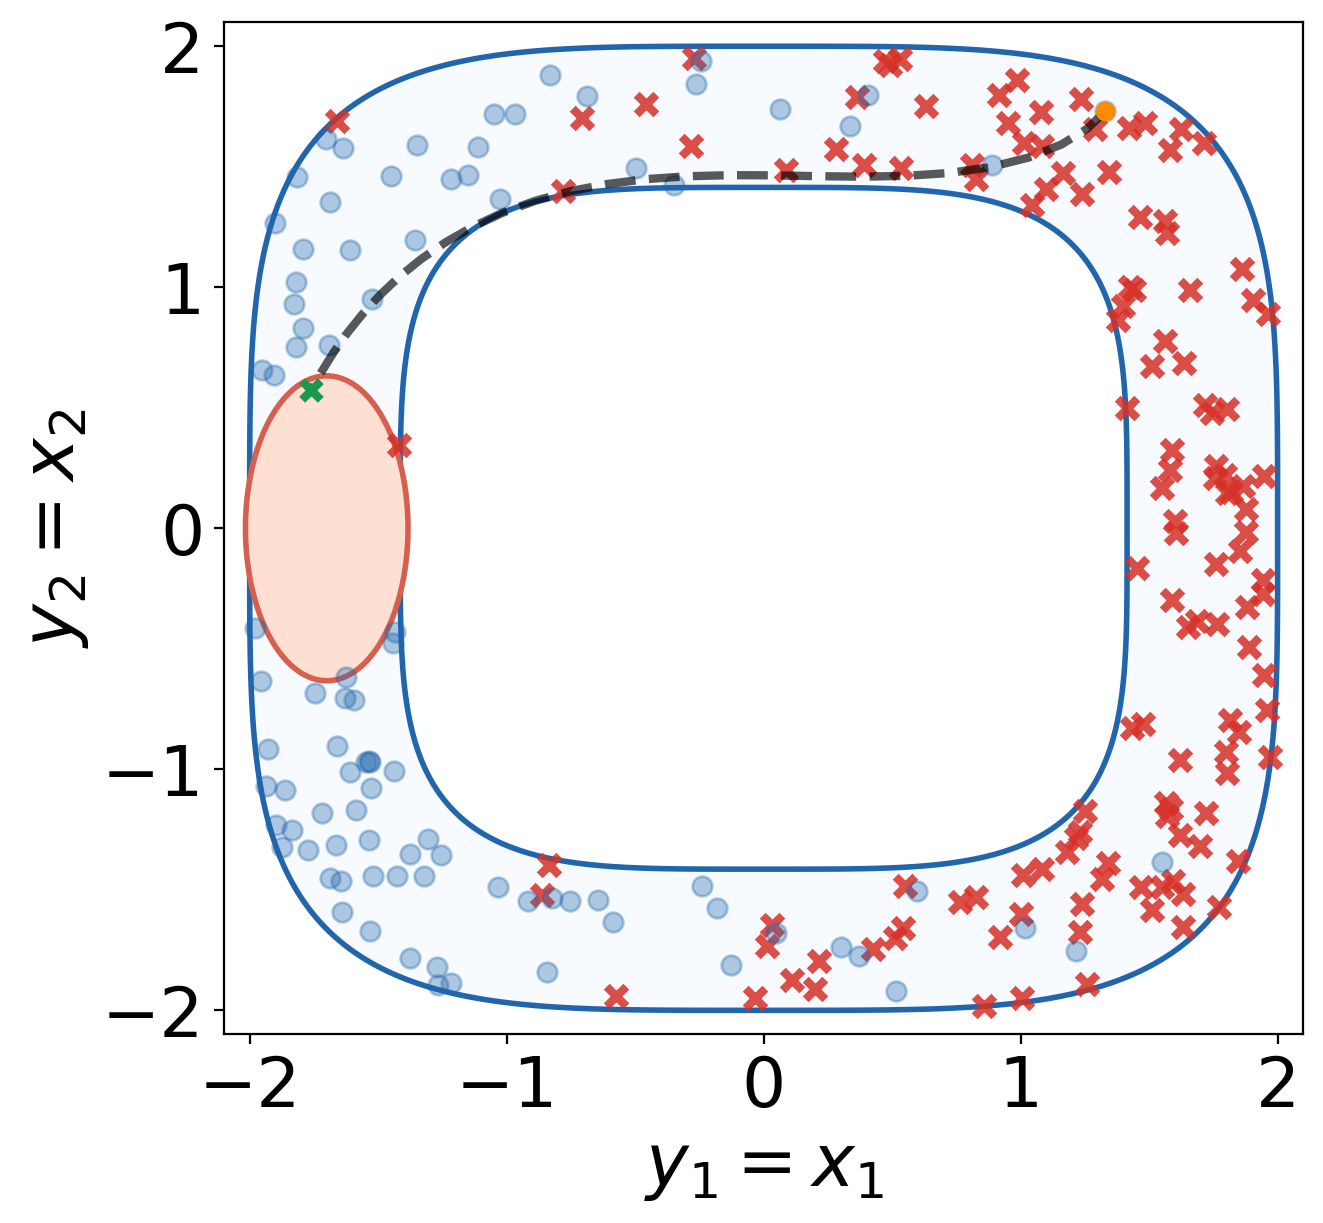

In [45]:
# ── Filter + visualise closed-loop trajectories + feasible/infeasible points ──
from functional import BetterColor

filtered = [
    (tt, tx, ty)
    for tt, tx, ty in zip(traj_t, traj_x, traj_y)
    if tt[-1] < T_max - 1e-6
    and tt[-1] >= T_min
    and float(np.squeeze(target_set_x_func(*tx[-1]))) <= phi_tol
][
    2:3
]  # only visualise 1 trajectory for now

print(
    f"Kept {len(filtered)}/{len(traj_t)} trajectories  "
    f"(removed {len(traj_t)-len(filtered)}: hit T_max or did not reach target)"
)
traj_t_plot, traj_x_plot, traj_y_plot = zip(*filtered) if filtered else ([], [], [])

# ── Grid for set contours ─────────────────────────────────────────────────────
n_grid = 400
y1_g = np.linspace(-2.1, 2.1, n_grid)
y2_g = np.linspace(-2.1, 2.1, n_grid)
Y1, Y2 = np.meshgrid(y1_g, y2_g)
Z_safe_y = safe_set_y_func(Y1, Y2)
Z_target_y = target_set_y_func(Y1, Y2)

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)

# Safe region
ax.contourf(
    Y1, Y2, Z_safe_y, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.3, zorder=1
)
ax.contour(Y1, Y2, Z_safe_y, levels=[0], colors=["#2166ac"], linewidths=2, zorder=2)
# Target region
ax.contourf(
    Y1, Y2, Z_target_y, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=3
)
ax.contour(Y1, Y2, Z_target_y, levels=[0], colors=["#d6604d"], linewidths=2, zorder=4)

# Feasible/infeasible initial states
ax.scatter(
    y_infeasible[0],
    y_infeasible[1],
    s=50,
    color="#d73027",
    alpha=0.85,
    marker="x",
    linewidths=3,
    label=f"MPC infeasible: {len(mpc_infeasible_idx)}",
    zorder=6,
)
ax.scatter(
    y_feasible[0],
    y_feasible[1],
    s=50,
    color="#2166ac",
    alpha=0.35,
    marker="o",
    label=f"MPC feasible: {len(mpc_feasible_idx)}",
    zorder=7,
)

# Closed-loop trajectories
for ty in traj_y_plot:
    ax.plot(
        ty[:, 0], ty[:, 1], color="black", lw=3, alpha=0.65, zorder=10, linestyle="--"
    )
    ax.scatter(
        ty[0, 0],
        ty[0, 1],
        s=45,
        c=[BetterColor.orange3()],
        marker="o",
        linewidths=0.4,
        zorder=20,
    )
    ax.scatter(
        ty[-1, 0],
        ty[-1, 1],
        s=45,
        c=[BetterColor.green0()],
        marker="x",
        linewidths=3.0,
        zorder=20,
    )

fs = 30
ax.set_xlabel("$y_1 = x_1$", fontsize=fs - 4)
ax.set_ylabel("$y_2 = x_2$", fontsize=fs - 4)
ax.xaxis.set_tick_params(labelsize=25)
ax.yaxis.set_tick_params(labelsize=25)
# ax.legend(fontsize=10, loc="upper right")
# ax.grid(True, alpha=0.3)
# ax.set_title(
#     f"Vanilla MPC closed-loop trajectories ({len(filtered)} shown)",
#     fontsize=11,
# )
plt.show()

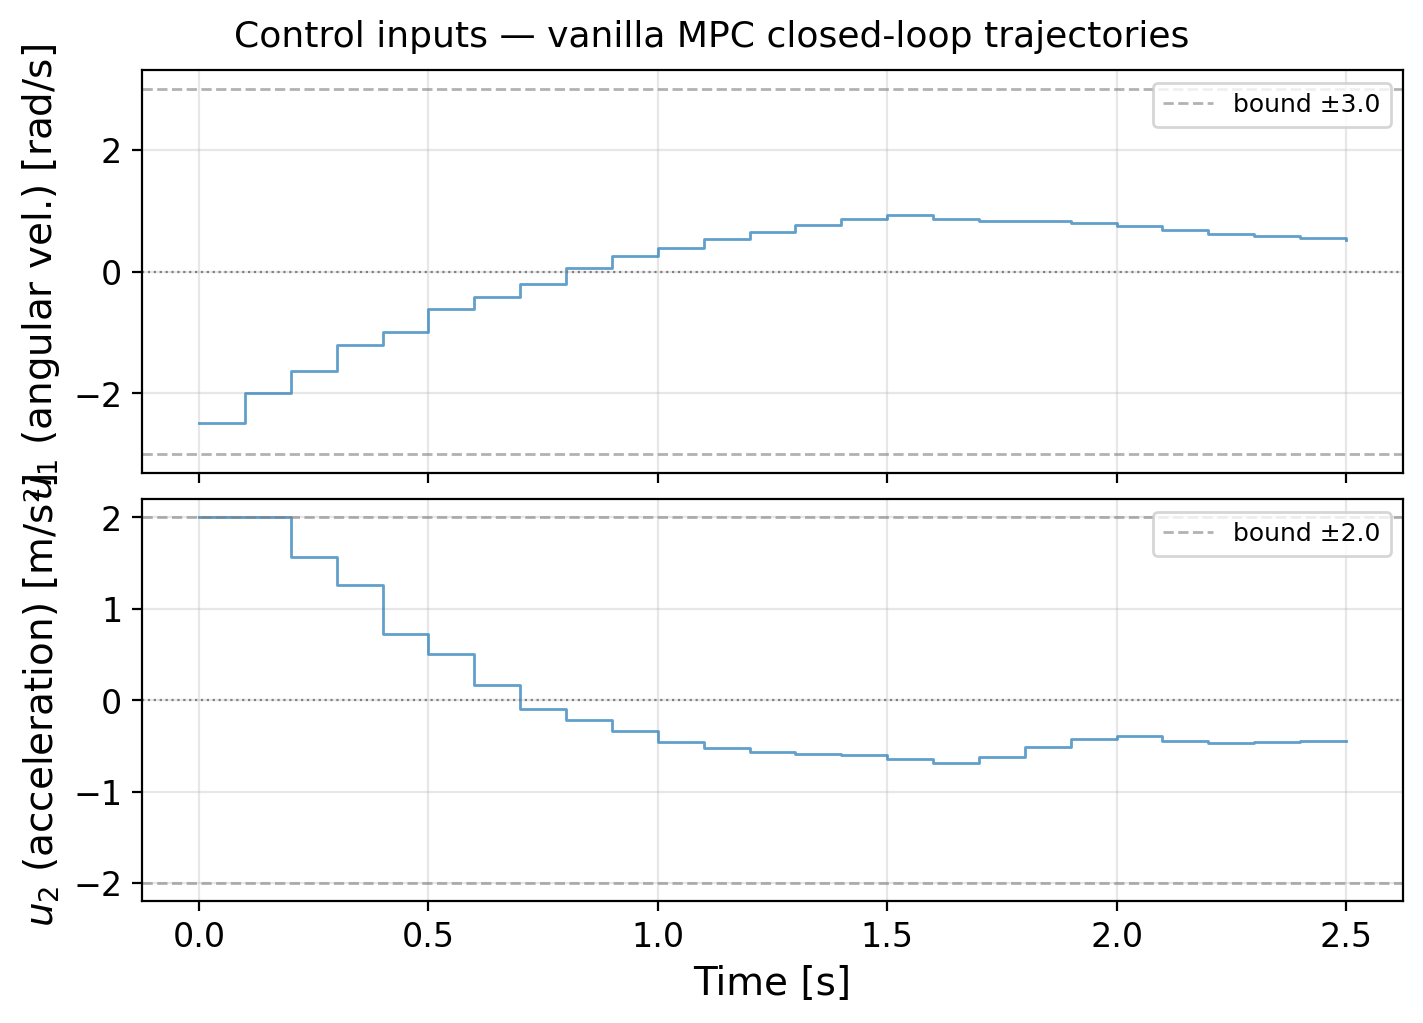

In [46]:
# ── Control inputs along filtered trajectories ────────────────────────────────
# MPC applies piecewise-constant controls over each dt_mpc interval;
# recover u1 = dtheta/dt and u2 = dv/dt from the simulated state.

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, axes = plt.subplots(
    2, 1, figsize=(700 * px_fig, 500 * px_fig), layout="constrained", sharex=True
)
fig.set_dpi(200)

for tt, tx in zip(traj_t_plot, traj_x_plot):
    if len(tt) < 2:
        continue
    dt_arr = np.diff(tt)
    u1_approx = np.diff(tx[:, 2]) / dt_arr  # dtheta/dt ≈ u1
    u2_approx = np.diff(tx[:, 3]) / dt_arr  # dv/dt     ≈ u2
    axes[0].step(tt[:-1], u1_approx, lw=1.0, alpha=0.7, where="post")
    axes[1].step(tt[:-1], u2_approx, lw=1.0, alpha=0.7, where="post")

for ax, lbl, bnd in zip(
    axes,
    ["$u_1$ (angular vel.) [rad/s]", "$u_2$ (acceleration) [m/s\u00b2]"],
    [u1_max, u2_max],
):
    ax.axhline(bnd, color="gray", lw=1.0, ls="--", alpha=0.6, label=f"bound ±{bnd}")
    ax.axhline(-bnd, color="gray", lw=1.0, ls="--", alpha=0.6)
    ax.axhline(0, color="gray", lw=0.8, ls=":")
    ax.set_ylabel(lbl, fontsize=14)
    ax.tick_params(labelsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="upper right")

axes[1].set_xlabel("Time [s]", fontsize=14)
fig.suptitle("Control inputs — vanilla MPC closed-loop trajectories", fontsize=13)
plt.show()